In [38]:
import pandas as pd
import numpy as np

# from Backtesting_Strategies.NB_01_SMA import SMA_L_range

# Creating the class (part 1) !-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!
# !-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!

In [129]:


# Klasse erstellen
class SMABacktester():
    ''' Class for vectorized backtesting of SMA-based trading strategies'''

    def __init__(self,symbol,SMA_S,SMA_L,start,end):
        '''
        Parameters
        ----------
        symbol: str
            ticker symbol (instrument) to be backtested
        SMA_S: int
            moving window in bars (e.g. days) for shorter SMA
        SMA_L: int
            moving window in bars (e.g. days) for longer SMA
        start: str
            start date for data import
        end: str
            end date for data import
        '''
        self.symbol=symbol
        self.SMA_S=SMA_S
        self.SMA_L=SMA_L
        self.start=start
        self.end=end
        self.results=None
        self.get_data()
        self.prepare_data()

    def __repr__(self):
        return f'SMABacktester(symbol={self.symbol},SMA_S={self.SMA_S},SMA_L={self.SMA_L},start={self.start},end={self.end})'

    def get_data(self):
        '''Imports the Data from forex_pairs.csv (source can be changed)
        '''
        raw=pd.read_csv('forex_pairs.csv',parse_dates=['Date'],index_col='Date')
        raw=raw[self.symbol].to_frame().dropna()
        raw=raw.loc[self.start:self.end].copy()
        raw.rename(columns={self.symbol:'price'},inplace=True)
        raw['returns']=np.log(raw/raw.shift(1))
        self.data=raw


    def prepare_data(self):
        '''Prepares data for strategy backtesting (strategy-specific)
        '''
        data=self.data.copy()
        data['SMA_S']=data['price'].rolling(self.SMA_S).mean()
        data['SMA_L']=data['price'].rolling(self.SMA_L).mean()
        self.data=data

    def set_parameters(self,SMA_S=None,SMA_L=None):
        '''Updates SMA parameters and prepared dataset
        '''
        if SMA_S is not None:
            self.SMA_S=SMA_S
            self.data['SMS_A']=self.data['price'].rolling(self.SMA_S).mean()
        if SMA_L is not None:
            self.SMA_L=SMA_L
            self.data['SMA_L']=self.data['price'].rolling(self.SMA_L).mean()

    def test_strategy(self):
        '''Backtests the SMS-based trading strategy
        '''
        data=self.data.copy().dropna()
        data['position']=np.where(data['SMA_S']>data['SMA_L'],1,-1)
        data['strategy']=data['position'].shift(1)*data['returns']
        data.dropna(inplace=True)
        data['creturns']=data['returns'].cumsum().apply(np.exp)
        data['cstrategy']=data['strategy'].cumsum().apply(np.exp)
        self.results=data

        perf=data['cstrategy'].iloc[-1] # absolute Performance
        outperf=perf-data['creturns'].iloc[-1] # Outperformance
        return round(perf,6),round(outperf,6)

    def plot_results(self):
        '''Plots the performance of the trading strategy and compares to "buy and hold"
        '''
        if self.results is None:
            print('Run test_strategy() first')
        else:
            title=f'{self.symbol} | SMA_S ={self.SMA_S} | SMA_L ={self.SMA_L}'
            self.results[['creturns','cstrategy']].plot(title=title,figsize=(12,8))

    def optimize_parameters(self, SMA_S_range,SMA_L_range):
        '''Finds the optimal strategy (global maximum) given the SMA parameter ranges

        Parameters
        ----------
        SMA_S_range, SMA_L_range: tuple
            tuples of the form (start,end,stepsize)
        '''
        combinations=list(product(range(*SMA_S_range),range(*SMA_L_range)))

        # alle Kombinationen testen
        results=[]
        for comb in combinations:
            self.set_parameters(comb[0], comb[1])
            results.append(self.test_strategy()[0])

        best_perf=np.max(results) #best performance
        opt=combinations[np.argmax(results)] # optimal parameters

        # Start/Setzen der optimalen Strategy
        self.set_parameters(opt[0],opt[1])
        self.test_strategy()

        # Erstellt ein DataFrame mit vielen Ergebnissen
        many_results=pd.DataFrame(data=combinations, columns=['SMA_S','SMA_L'])
        many_results['performance']=results
        self.results_overview=many_results

        return opt, best_perf

In [40]:
# Instanz des Instruments Australiendollar/Eur erstellen (Instantiation)
tester=SMABacktester('AUDEUR=X',50,200,'2004-01-01','2020-06-30')


In [41]:
raw=pd.read_csv('forex_pairs.csv',parse_dates=['Date'],index_col='Date')
raw

,AUDEUR=X,EURUSD=X,USDGBP=X
Date,,,
2004-01-01,0.59780,1.258194,0.56016
2004-01-02,0.60314,1.258194,0.55751
2004-01-05,0.60467,1.268698,0.55334
2004-01-06,0.60350,1.272103,0.54906
2004-01-07,0.60728,1.264095,0.55012
...,...,...,...
2020-06-24,0.61349,1.131235,0.79841
2020-06-25,0.60938,1.125087,0.80561
2020-06-26,0.61373,1.122208,0.80480


In [42]:
raw=raw['AUDEUR=X'].to_frame().dropna()
raw

,AUDEUR=X
Date,
2004-01-01,0.59780
2004-01-02,0.60314
2004-01-05,0.60467
2004-01-06,0.60350
2004-01-07,0.60728
...,...
2020-06-24,0.61349
2020-06-25,0.60938
2020-06-26,0.61373


In [43]:
raw=raw.loc['2010-01-01':'2012-12-31'].copy() # setting time period
raw

,AUDEUR=X
Date,
2010-01-01,0.62402
2010-01-04,0.63230
2010-01-05,0.63430
2010-01-06,0.63860
2010-01-07,0.64060
...,...
2012-12-25,0.78620
2012-12-26,0.78680
2012-12-27,0.78340


In [44]:
# replace column name with 'price'
raw.rename(columns={'AUDEUR=X':'price'},inplace=True)
raw

,price
Date,
2010-01-01,0.62402
2010-01-04,0.63230
2010-01-05,0.63430
2010-01-06,0.63860
2010-01-07,0.64060
...,...
2012-12-25,0.78620
2012-12-26,0.78680
2012-12-27,0.78340


In [45]:
# calculate and assign simple returns

raw['returns']=np.log(raw/raw.shift(1))
raw

,price,returns
Date,,
2010-01-01,0.62402,NaN
2010-01-04,0.63230,0.013182
2010-01-05,0.63430,0.003158
2010-01-06,0.63860,0.006756
2010-01-07,0.64060,0.003127
...,...,...
2012-12-25,0.78620,-0.002921
2012-12-26,0.78680,0.000763
2012-12-27,0.78340,-0.004331


In [46]:
raw['SMA_S']=raw['price'].rolling(50).mean()
raw['SMA_L']=raw['price'].rolling(200).mean()

In [47]:
raw

,price,returns,SMA_S,SMA_L
Date,,,,
2010-01-01,0.62402,NaN,NaN,NaN
2010-01-04,0.63230,0.013182,NaN,NaN
2010-01-05,0.63430,0.003158,NaN,NaN
2010-01-06,0.63860,0.006756,NaN,NaN
2010-01-07,0.64060,0.003127,NaN,NaN
...,...,...,...,...
2012-12-25,0.78620,-0.002921,0.803610,0.805435
2012-12-26,0.78680,0.000763,0.803618,0.805410
2012-12-27,0.78340,-0.004331,0.803462,0.805372


# Creating the class (part 2)

In [48]:
tester.symbol

'AUDEUR=X'

In [49]:
tester.SMA_L

200

In [50]:
tester.results

In [51]:
tester.get_data()

,price,returns,SMA_S,SMA_L
Date,,,,
2004-01-01,0.59780,NaN,NaN,NaN
2004-01-02,0.60314,0.008893,NaN,NaN
2004-01-05,0.60467,0.002533,NaN,NaN
2004-01-06,0.60350,-0.001937,NaN,NaN
2004-01-07,0.60728,0.006244,NaN,NaN
...,...,...,...,...
2020-06-24,0.61349,-0.001612,0.600626,0.603695
2020-06-25,0.60938,-0.006722,0.601243,0.603684
2020-06-26,0.61373,0.007113,0.601806,0.603706


In [52]:
tester.data

,price,returns,SMA_S,SMA_L
Date,,,,
2004-01-01,0.59780,NaN,NaN,NaN
2004-01-02,0.60314,0.008893,NaN,NaN
2004-01-05,0.60467,0.002533,NaN,NaN
2004-01-06,0.60350,-0.001937,NaN,NaN
2004-01-07,0.60728,0.006244,NaN,NaN
...,...,...,...,...
2020-06-24,0.61349,-0.001612,0.600626,0.603695
2020-06-25,0.60938,-0.006722,0.601243,0.603684
2020-06-26,0.61373,0.007113,0.601806,0.603706


# Creating the class (part 3)

- Setting new SMA Parameters

In [53]:
tester.SMA_S

50

In [54]:
tester.SMA_L

200

In [55]:
tester.data

,price,returns,SMA_S,SMA_L
Date,,,,
2004-01-01,0.59780,NaN,NaN,NaN
2004-01-02,0.60314,0.008893,NaN,NaN
2004-01-05,0.60467,0.002533,NaN,NaN
2004-01-06,0.60350,-0.001937,NaN,NaN
2004-01-07,0.60728,0.006244,NaN,NaN
...,...,...,...,...
2020-06-24,0.61349,-0.001612,0.600626,0.603695
2020-06-25,0.60938,-0.006722,0.601243,0.603684
2020-06-26,0.61373,0.007113,0.601806,0.603706


In [56]:
tester.data.isna().sum()

price        0
returns      1
SMA_S       49
SMA_L      199
dtype: int64

In [57]:
# neuen Wert von 250 zuweisen
tester.SMA_L=250

In [58]:
tester.SMA_L

250

In [59]:
# tester.data.isna().sum() erneut ausführen allerdings wird sich die Ausgabe dadurch nicht ändern
tester.data.isna().sum()

price        0
returns      1
SMA_S       49
SMA_L      199
dtype: int64

In [60]:
# Erst die Änderung der Parameter durch set_parameter ändert SMA_S/SMA_L
tester.set_parameteres(SMA_S=50,SMA_L=250)
tester.SMA_S

50

In [61]:
tester.SMA_L

250

In [62]:

tester.data.isna().sum()

price        0
returns      1
SMA_S       49
SMA_L      249
SMS_A       49
dtype: int64

# Creating the class (part 4)

- Testing a Strategy

In [63]:
# Testopbjekt: Instanz des Instruments Australiendollar/Eur erstellen (Instantiation)
tester=SMABacktester('EURUSD=X',50,200,'2004-01-01','2020-06-30')

In [64]:
tester.test_strategy()

(np.float64(1.2835), np.float64(0.367674))

In [65]:
tester.data

,price,returns,SMA_S,SMA_L
Date,,,,
2004-01-01,1.258194,NaN,NaN,NaN
2004-01-02,1.258194,0.000000,NaN,NaN
2004-01-05,1.268698,0.008313,NaN,NaN
2004-01-06,1.272103,0.002681,NaN,NaN
2004-01-07,1.264095,-0.006315,NaN,NaN
...,...,...,...,...
2020-06-24,1.131235,0.002892,1.101794,1.103430
2020-06-25,1.125087,-0.005449,1.102486,1.103540
2020-06-26,1.122208,-0.002562,1.103213,1.103627


In [66]:
tester.results

,price,returns,SMA_S,SMA_L,position,strategy,creturns,cstrategy
Date,,,,,,,,
2004-10-07,1.229906,0.001475,1.221840,1.226081,-1,-0.001475,1.001476,0.998526
2004-10-08,1.241003,0.008982,1.222628,1.225995,-1,-0.008982,1.010511,0.989598
2004-10-11,1.238405,-0.002095,1.223352,1.225843,-1,0.002095,1.008396,0.991673
2004-10-12,1.232104,-0.005102,1.223888,1.225643,-1,0.005102,1.003265,0.996746
2004-10-13,1.234903,0.002270,1.224466,1.225497,-1,-0.002270,1.005545,0.994486
...,...,...,...,...,...,...,...,...
2020-06-24,1.131235,0.002892,1.101794,1.103430,-1,-0.002892,0.921130,1.271272
2020-06-25,1.125087,-0.005449,1.102486,1.103540,-1,0.005449,0.916125,1.278218
2020-06-26,1.122208,-0.002562,1.103213,1.103627,-1,0.002562,0.913781,1.281497


# Creating the Class (Part 5)

- Plotting the results

In [67]:
tester=SMABacktester('EURUSD=X',50,200,'2004-01-01','2020-06-30')

In [68]:
tester.plot_results()

Run test_strategy() first


In [69]:
tester.test_strategy()

(np.float64(1.2835), np.float64(0.367674))

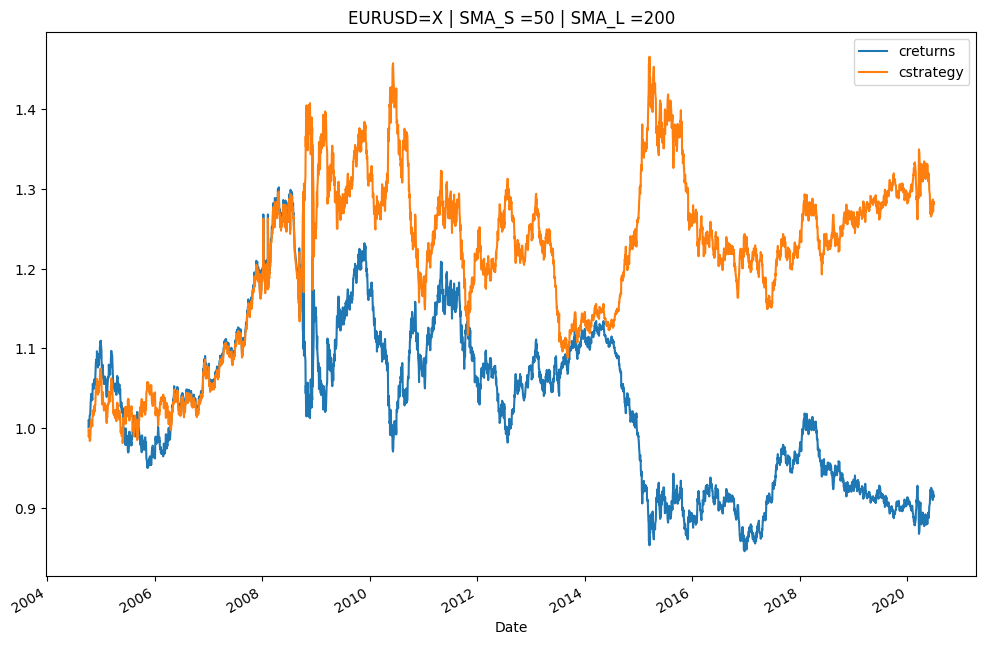

In [70]:
tester.plot_results()

# Creating the Class (Part 6)

- Strategieoptimierung

In [89]:
# Testopbjekt
tester=SMABacktester('EURUSD=X',50,200,'2004-01-01','2020-06-30')

In [90]:
tester.test_strategy()

(np.float64(1.2835), np.float64(0.367674))

        alle Kombinationen testen
        results=[]
        for comb in combinations:
            self.set_parameters(comb[0], comb[1])
            results.append(self.test_strategy()[0])
        best_perf=np.max(results) #best performance
        opt=combinations[np.argmax(results)] # optimal parameters

        # Start/Setzen der optimalen Strategy
        self.set_parameters(opt[0],opt[1])
        self.test_strategy()

Im Folgenden werden die Parameter als Wertebereich übergeben. Für Short: 10-50 in Einserschritten und für Long: 100-252 in Einserschritten (252 steht für die möglichen Handelstage im Jahr)

In [91]:
tester.optimize_parameters((10,50,1),(100,252,1))

((10, 133), np.float64(2.331171))

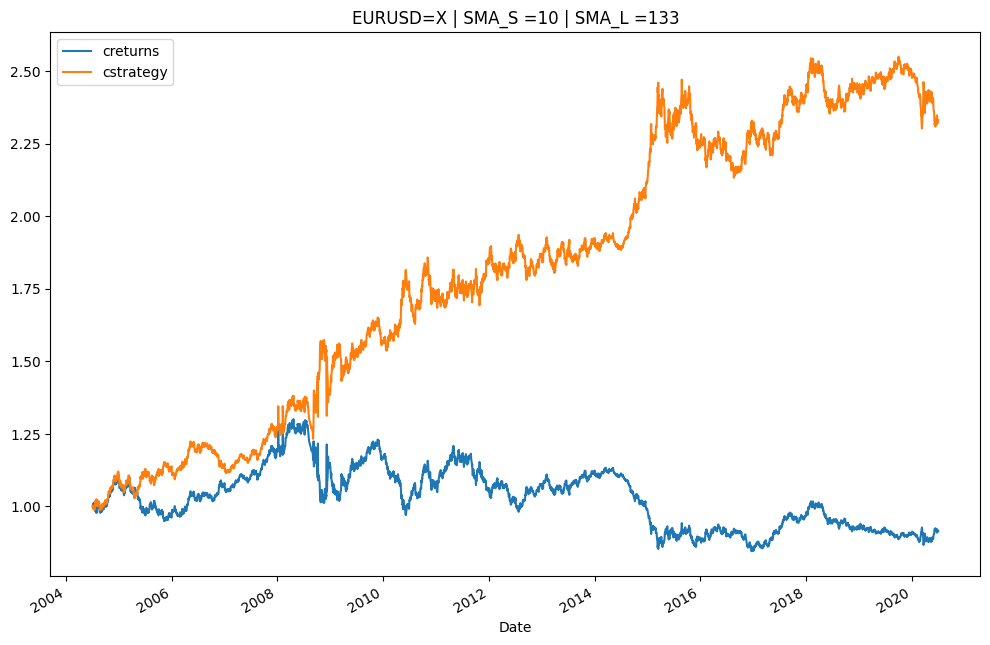

In [92]:
tester.plot_results()

In [93]:
tester.results_overview

,SMA_S,SMA_L,performance
0,10,100,1.943935
1,10,101,1.728979
2,10,102,1.738317
3,10,103,1.656821
4,10,104,1.876096
...,...,...,...
6075,49,247,1.249558
6076,49,248,1.262063
6077,49,249,1.245627
6078,49,250,1.258254


# Creating the Class (Part 7)

- Splitting get_data() and adding prepare_data()

In [120]:
tester=SMABacktester('EURUSD=X',50,200,'2004-01-01','2020-06-30')

In [121]:
tester.data

,price,returns,SMA_S,SMA_L
Date,,,,
2004-01-01,1.258194,NaN,NaN,NaN
2004-01-02,1.258194,0.000000,NaN,NaN
2004-01-05,1.268698,0.008313,NaN,NaN
2004-01-06,1.272103,0.002681,NaN,NaN
2004-01-07,1.264095,-0.006315,NaN,NaN
...,...,...,...,...
2020-06-24,1.131235,0.002892,1.101794,1.103430
2020-06-25,1.125087,-0.005449,1.102486,1.103540
2020-06-26,1.122208,-0.002562,1.103213,1.103627


In [122]:
tester.test_strategy()

(np.float64(1.2835), np.float64(0.367674))

In [123]:
tester.prepare_data()

# Creating the Class (Part 8)

- String Representation & Docstrings

In [124]:
tester

In [130]:
tester.optimize_parameters()

TypeError: SMABacktester.optimize_parameters() missing 2 required positional arguments: 'SMA_S_range' and 'SMA_L_range'